In [1]:
from notebook_env import *
import scipy.interpolate

In [2]:
build_game = lambda f_A, f_B=None, p_vec=np.linspace(0,1,101): (
    pd.DataFrame([
        {
            'p_A': 1-p_B,
            'p_B': p_B,
            'acc_A': f_A(p_B),
            'acc_B': (f_B or (lambda p: f_A(1-p)))(p_B),
        }
        for p_B in p_vec
    ])
    .assign(acc_p=lambda df: df['acc_A']*df['p_A'] + df['acc_B']*df['p_B'])
    .set_index('p_B')
)


In [3]:
def annotate(ax, coords, alpha=1):
    ax.annotate(
        text='$\\mathrm{acc}_A$',
        xy=coords[0],
        color=evoml.analysis.group_cmap(1.0),
        alpha=alpha,
    )
    ax.annotate(
        text='$\\mathrm{acc}_B$',
        xy=coords[1],
        color=evoml.analysis.group_cmap(0.0),
        alpha=alpha,
    )
    if len(coords)>3:
        ax.annotate(
            text='$\\mathrm{acc}_{\\bm{p}}$',
            xy=coords[2],
            color='tab:blue',
            alpha=alpha,
        )

Figure saved as ./output/prediction_game_types.pdf


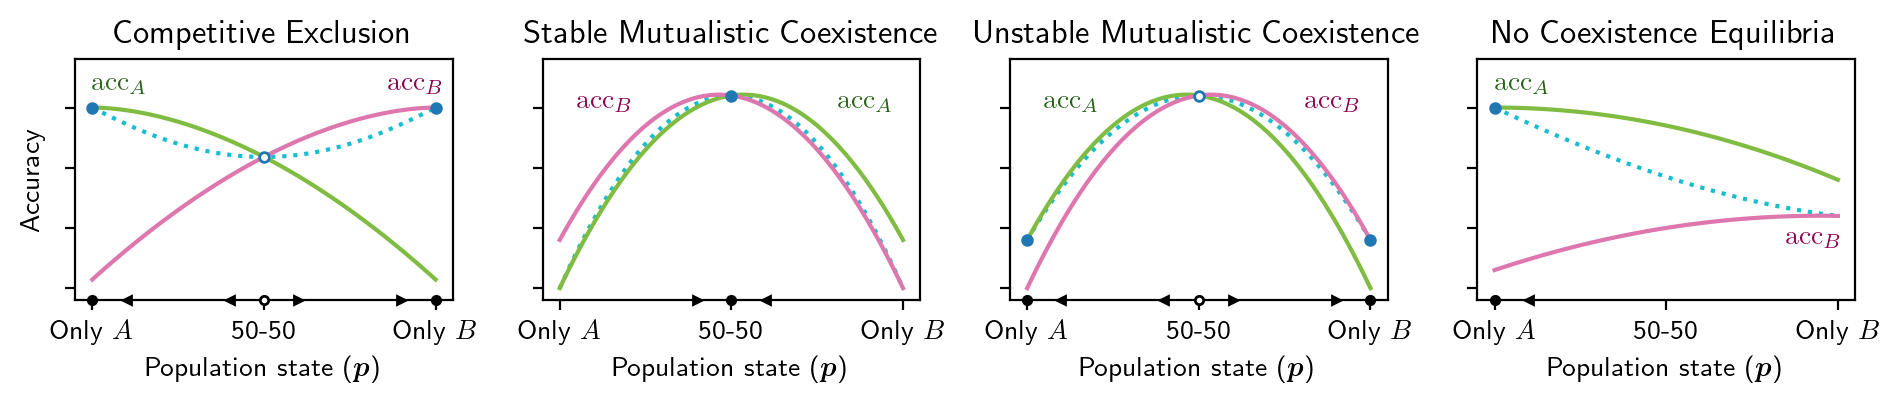

In [4]:

fig, axs = evoml.create_figure(
    1,4,
    figsize=(9.5,1.9),
    sharey=True,
    constrained_layout={'w_pad':0.1},
)
axs_it = iter(axs.ravel())

def plot_population_game(**kwargs):
    kwargs['annotations'].pop('acc_p')
    return evoml.plot_population_game(**kwargs)
    
ax = next(axs_it)
plot_population_game(
    game_df=build_game(lambda p: 0.95-p**1.8/7),
    ax=ax,
    equilibria=[
        (0,True),
        (0.5,False),
        (1.0,True),
    ],
    equilibria_kwargs=dict(
        d=0.1,
        markersize=3,
    ),
    ax_kwargs={'ylim':(0.79,0.99)},
    annotations={
        'acc_A': (0.0,0.965),
        'acc_B': (0.86,0.965),
        'acc_p': (0.78,0.903),
    }
)
ax.set(
    title='Competitive Exclusion',
    yticklabels=[],
)

ax = next(axs_it)
plot_population_game(
    # game_df=build_game(lambda p: 0.95-(1-p)**2.2/7),
    game_df=build_game(
        lambda p: scipy.interpolate.interp1d(
            (0,0.5,1.0),
            (0.84,0.96,0.80),
            kind='quadratic',
        )(1-p).item()
    ),
    ax=ax,
    equilibria=[
        (0.5,True),
    ],
    equilibria_kwargs=dict(
        d=0.1,
        markersize=3,
    ),
    annotations={
        'acc_A': (0.81,0.95),
        'acc_B': (0.05,0.95),
        'acc_p': (0.455,0.932),
    }
)
ax.set(
    title='Stable Mutualistic Coexistence',
    yticklabels=[],
)

ax = next(axs_it)
plot_population_game(
    game_df=build_game(
        lambda p: scipy.interpolate.interp1d(
            (0,0.5,1.0),
            (0.84,0.96,0.80),
            kind='quadratic',
        )(p).item()
    ),
    ax=ax,
    equilibria=[
        (0,True),
        (0.5,False),
        (1.0,True),
    ],
    equilibria_kwargs=dict(
        d=0.1,
        markersize=3,
    ),
    annotations={
        'acc_A': (0.05,0.95),
        'acc_B': (0.81,0.95),
        'acc_p': (0.455,0.932),
    }
)
ax.set(
    title='Unstable Mutualistic Coexistence',
    yticklabels=[],
)

ax = next(axs_it)
plot_population_game(
    game_df=build_game(
        lambda p: scipy.interpolate.interp1d(
            (0,0.5,1.0),
            (0.95,0.935,0.89),
            kind='quadratic',
        )(p).item(),
        lambda p: scipy.interpolate.interp1d(
            (0,0.5,1.0),
            (0.815,0.85,0.86),
            kind='quadratic',
        )(p).item(),
    ),
    ax=ax,
    equilibria=[
        (0,True),
        # (0.5,False),
        # (1.0,True),
    ],
    equilibria_kwargs=dict(
        d=0.1,
        markersize=3,
    ),
    annotations={
        'acc_A': (0.0,0.965),
        'acc_B': (0.85,0.837),
        'acc_p': (0.55,0.898),
    },
)
ax.set(
    title='No Coexistence Equilibria',
    yticklabels=[],
)

fig.save_and_download('./output/prediction_game_types.pdf')